In [1]:
# 지도 학습의 한 종류인 '회귀 문제'를 이해하고
# KNN 알고리즘을 사용해 농어의 무게를 예측하는 회귀 문제를 풀어볼겁니다

# 회귀 (Regression)
KNN regression 사용

In [2]:
# 지도학습은 target y 의 형태에 따라
# 회귀(regression) 와 분류 (classification) 으로 나뉜다.

# '분류' 는 몇개의 클래스 중 하나로 분류 하는 문제
# '회귀' 는 임의의 어떤 숫자를 예측 하는 문제
#   - ex)내년 경제 성장률 예측, 주가 예측
#        주문후 배달 도착시간 예측
#   - 회귀 문제의 출력은 정해진 클래스가 아니라 '임의의 수치'

In [3]:
# 농어의 '길이, 높이, 두께' 측정한 데이터로 '무게'를 예측하기
# 무게는 '어떠한 숫자' 도 될수 있다 (회귀문제!)


# ■ k-최근접 이웃 회귀
k-nearest neighbor (KNN) regression

In [4]:
# 우선 'k-최근접 이웃 분류 알고리즘' 와 'k-최근접 이웃 회귀 알고리즘' 에 대해 알아보자

In [5]:
# k-최근접 이웃 분류 알고리즘

# 1. 예측하려는 샘플에 가장 가까운 샘플 k개를 선택
# 2. 이 샘플들의 클래스를 확인하여 다수 클래스를 새로운 샘플의 클래스로 예측.

In [6]:
# k-최근접 이웃 회귀 알고리즘
# '분류' 와 같은 방식으로, 예측하려는 샘플에 가장 가까운 샘플 k개를 선택.
# 하지만 회귀이기 때문에 이웃한 샘플의 타깃은 어떤 클래스가 아니라 '임의의 수치' 가 된다.
# 이웃 샘플의 수치를 사용해 새로운 샘플 X 의 타킷을 예측하는 방법은 ?
#    => 바로 이 수치들의 평균값을 구하면 된다.

# 데이터 준비

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [8]:
# TODO
base_path = r'F:\KDT2508\dataset'


In [9]:
file_path = os.path.join(base_path, 'fish.csv')
fish_df = pd.read_csv(file_path)
fish_df

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...
154,Smelt,12.2,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,14.3,15.2,2.8728,2.0672


In [10]:
# 농어의 길이(특징, feature) 가 주어졌을때 무게(target) 를 예측해보자.

In [11]:
# 농어의 길이 (특성: feature)
perch_length = fish_df[fish_df.Species == 'Perch']['Length'].values
print(perch_length)

# 농어의 무게(target 값!)
perch_weight = fish_df[fish_df.Species == 'Perch']['Weight'].values
print(perch_weight)


[ 8.4 13.7 15.  16.2 17.4 18.  18.7 19.  19.6 20.  21.  21.  21.  21.3
 22.  22.  22.  22.  22.  22.5 22.5 22.7 23.  23.5 24.  24.  24.6 25.
 25.6 26.5 27.3 27.5 27.5 27.5 28.  28.7 30.  32.8 34.5 35.  36.5 36.
 37.  37.  39.  39.  39.  40.  40.  40.  40.  42.  43.  43.  43.5 44. ]
[   5.9   32.    40.    51.5   70.   100.    78.    80.    85.    85.
  110.   115.   125.   130.   120.   120.   130.   135.   110.   130.
  150.   145.   150.   170.   225.   145.   188.   180.   197.   218.
  300.   260.   265.   250.   250.   300.   320.   514.   556.   840.
  685.   700.   700.   690.   900.   650.   820.   850.   900.  1015.
  820.  1100.  1000.  1100.  1000.  1000. ]


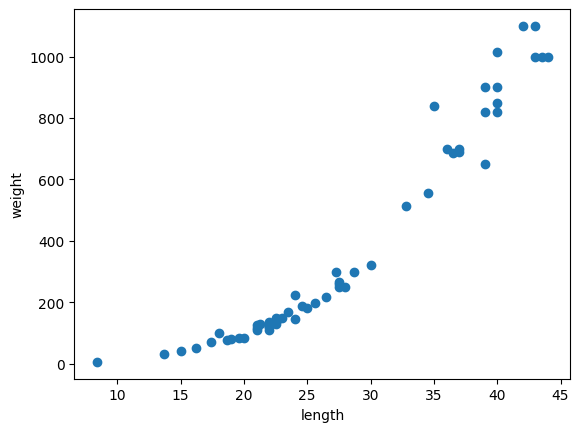

In [12]:
# 이 데이터 들이 어떠한 형태를 보여주는지 scatter plot(산점도) 를 그려 보자
plt.scatter(perch_length, perch_weight)
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [13]:
# 이제 데이터를 training / test 셋으로 나누겠습니다.
from sklearn.model_selection import train_test_split

In [14]:
# 학습교안과 동일한 결과를 유지하기 위해  ransom_state 값을 주겠습니다.  디폴트 test 비율 30%
train_input, test_input, train_target, test_target = train_test_split(
    perch_length, perch_weight, random_state=42)

In [15]:
# 또 명심!
# scikit-learn 머신러닝에 사용할(학습, 테스트, 예측) 데이터세트는 feature 들의 벡터여야 한다.
# (즉 2차원 배열 형태)

In [16]:
train_input = train_input.reshape(-1,1)
test_input = test_input.reshape(-1,1)
print(train_input.shape, test_input.shape)

(42, 1) (14, 1)


# 결정 계수 ($R^2$)


KNeighborsRegressor 의 score 값

In [17]:
# KNeighborsRegressor 클래스:
# scikit-learn  에서 k-최근접 이웃 회귀 알고리즘을 구현한 클래스
#  KNeighborsClassifier 와 비슷
from sklearn.neighbors import KNeighborsRegressor

https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html#kneighborsregressor

```python
class sklearn.neighbors.KNeighborsRegressor(
  n_neighbors=5,
  *,
  weights='uniform',
  algorithm='auto',
  leaf_size=30,
  p=2,
  metric='minkowski',
  metric_params=None,
  n_jobs=None)
```

In [18]:
# 모델 생성
knr = KNeighborsRegressor()

# k-최근접 이웃 회귀 모델을 훈련합니다
knr.fit(train_input, train_target)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [19]:
# 점수 확인
knr.score(test_input, test_target)


0.992809406101064

In [20]:
# '분류' 문제의 경우 test 세트의 샘플을 정확하게 분류한 개수의 비율이다. (accuracy: 정확도)
# '회귀' 문제는 정확한 숫자를 맞힌다는것이 거의 불가능하다.
# 예측하는 값이나 타킷 모두 임의의 수치이기 때문이다.

# '회귀' 의 경우 평가방식이 조금 다르다
# 이 점수를 '결정계수' (Coefficient of determination) 이라고 부름.
# 간단히 R² 라고도 부름

# 이 값은 다음과 같은 식으로 계산됨

#           (target - 예측)² 의 합
#  R² = 1 - ──────────────────
#           (target - 평균)² 의 합

In [21]:
"""
샘플의 타켓과 예측한 값의 차이를 제곱하여 더함.
그 다음 타겟과 타켓 평균의 차이를 제곱하여 더한 값으로 나누게 됨.
만약 타킷의 평균 정도를 예측하는 수준이라면 (즉 분자와 분모가 비슷해져) R² 는 0 에 가까와 지고,
예측이 타켓에 아주 가까워 지면 (분자가 0에 가까워지기 때문에) 1에 가까운 값이 됨.
"""

None

In [22]:
# sklearn.metrics 패키지에는 다양한 평가 측정 도구를 제공한다.
# 그 중에서 mean_absolute_error() 는 타깃과 예측의 절대값 오차를 평균하여 반환함.
from sklearn.metrics import mean_absolute_error

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html#sklearn.metrics.mean_absolute_error

```python
sklearn.metrics.mean_absolute_error(
  y_true, y_pred,
  *,
  sample_weight=None, multioutput='uniform_average')
```


In [23]:
# 테스트 세트에 대한 예측을 만듭니다
test_prediction = knr.predict(test_input)
test_prediction

array([  60. ,   79.6,  248. ,  122. ,  136. ,  847. ,  311.4,  183.4,
        847. ,  113. , 1010. ,   60. ,  248. ,  248. ])

In [24]:
test_target

array([   5.9,  100. ,  250. ,  130. ,  130. ,  820. ,  320. ,  188. ,
        900. ,  125. , 1000. ,   51.5,  250. ,  300. ])

In [25]:
# 테스트 세트에 대한 평균 절댓값 오차를 계산합니다
mae = mean_absolute_error(test_target, test_prediction)
print(mae)

19.157142857142862


In [26]:
# 이번에는 test 세트가 아닌 train 세트로 평가해보자.  test세트 점수와는 다를 것이다.
# ↓과연 여기서 무엇을 발견할수 있을까?

# 과대적합(Overfit) vs 과소적합(Underfit)  

In [27]:
# train 데이터 를 사용하여 R² 점수를 확인해보자.
knr.score(train_input, train_target)

0.9698823289099254

In [28]:
"""
어떤 값이 더 높은가?  이상하지 않은가?  왜?


모델을 train 세트로 훈련하면 train 세트에 잘 맞는(fit) 모델이 만들어진다.
이 모델을 train 세트와 test 세트로 평가하면 누가 더 높은 점수가 나와야 하나?
당연히 train 세트가 더 높게 나와야 겠죠?  (풀어보았던 문제집을 다시 푸는 거니까!)


그런데 머신러닝 학습의 목표는 '무엇'인가?
train 세트에서의 높은 점수인가?
아니다! test 세트 (혹은 실제 관측된 데이터를 예측할때)  높은 점수 이다.


만약, train 세트에서의 점수가 높았는데, test 세트에서의 점수가 낮다면
  => 모델이 train 세트에 과대적합(overfit) 되었다고 합니다.
     즉, 모델이 train 세트에만 잘 맞는 모델로 학습된겁니다.
     (문제집의 문제는 잘 푸는데, 막상 시험에 나오는 문제를 못 맞추는 것)
     나중에 실전에 투입하여 새로운 데이터에 대한 예측을 할때 잘 동작 하지 않을 가능성 큼.


반대로, 훈련세트보다 테스트 세트의 점수가 높거나, 두 점수가 모두 너무 낮은 경우는
  => 모델이 train 세트에 과소적합(underfit) 되었다고 합니다
     즉, 모델이 너무 '단순' 하여 train 세트에 적절히 훈련되지 않은 경우.


※ 데이터 세트 크기가 너무 작아도 위와 같은 현상들이 발생할수 있다.
"""
None

In [29]:
# 이 문제를 어떻게 해결할수 있나?
# 모델을 좀 더 복잡하게 만들어 보자
# KNN 알고지름에서 알고리즘 복잡도를 높이는 방법은 이웃의 개수 K를 줄이는 것이다. 
# 이웃의 개수를 줄이면 훈련 세트에 있는 '국지적인 패턴' 에 민감해지고,
# 이웃의 개수를 늘리면 데이터 전반에 있는 '일반적인 패턴' 을 따르게 될것이다.

In [30]:
# 이웃의 갯수(k)를 3으로 설정합니다
knr.n_neighbors = 3

# 모델을 다시 훈련합니다
knr.fit(train_input, train_target)
print(knr.score(train_input, train_target))


0.9804899950518966


In [31]:
# ↑ k 값을 줄였더니 train 세트의 R² 점수가 높아졌다.

# ↓이제 test 세트의 점수를 확인해보자

In [32]:
print(knr.score(test_input, test_target))


0.9746459963987609


# 단순한 모델 vs 복잡한 모델에 대한 시각화
k 값의 변화에 따른 결과 변화

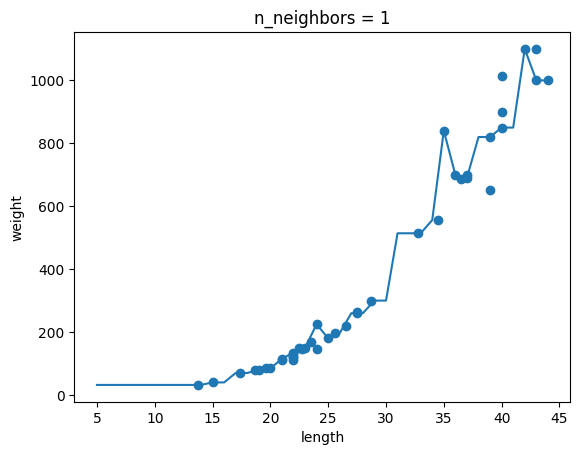

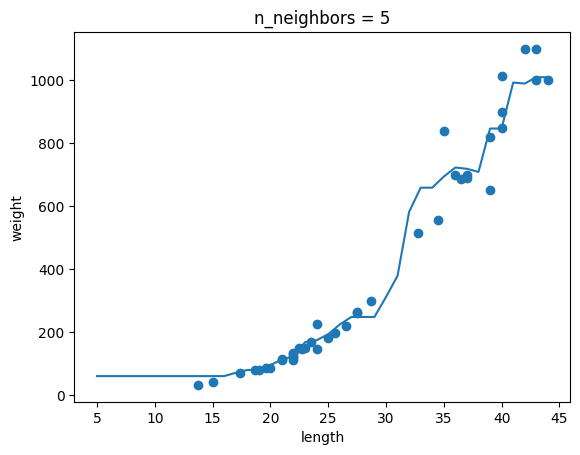

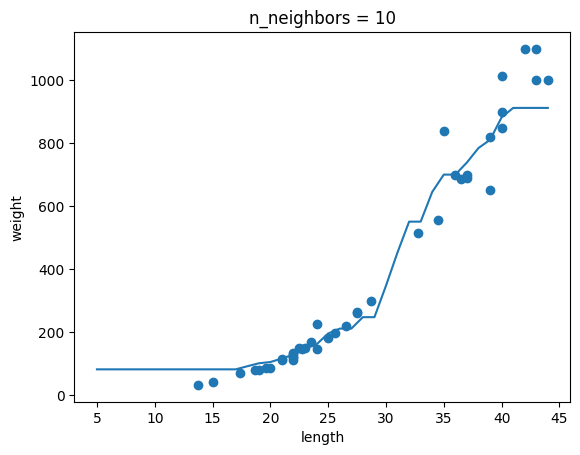

In [33]:
# k-최근접 이웃 회귀 객체를 만듭니다
knr = KNeighborsRegressor()
# 농어의 length를 5에서 45까지 x 좌표를 만듭니다
x = np.arange(5, 45).reshape(-1, 1)  # 예측값으로 만들어야 하기에 feature vector 로 만든다

# n = 1, 5, 10일 때 예측 결과를 그래프로 그립니다.
for n in [1, 5, 10]:
    # 모델 훈련
    knr.n_neighbors = n
    knr.fit(train_input, train_target)

    # 지정한 범위 x에 대한 예측 구하기
    prediction = knr.predict(x)

    # 훈련 세트와 예측 결과 그래프 그리기
    plt.scatter(train_input, train_target)
    plt.plot(x, prediction)

    plt.title('n_neighbors = {}'.format(n))  # plt.title(f'n_neighbors = {n}')
    plt.xlabel('length')
    plt.ylabel('weight')
    plt.show()

# KNN Regressor 의 문제점

In [34]:
# 상황]  학습된 모델에 길이가 큰 50cm 농어의 무게를 예측해보기로 했다.  과연 어떠할까?


In [35]:
# k-최근접 이웃 개수를 3으로 하는 회귀 모델을 훈련합니다
knr = KNeighborsRegressor(n_neighbors=3)
knr.fit(train_input, train_target)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [36]:
# 위 모델을 사용하여 길이가 50cm 인 농어의 무게를 예측해봅니다.
print(knr.predict([[50]]))

[1033.33333333]


In [37]:
# 'train세트' 와 '50cm 농어' 그리고 이 농어의 'knn 이웃'을 시각화 (scatter plot) 으로 시각화 해보자.
# KNN 의 kneighbors() 메소드를 사용하면 가장 가까운 이웃까지의 거리와 이웃샘플의 인덱스를 얻을수 있다.


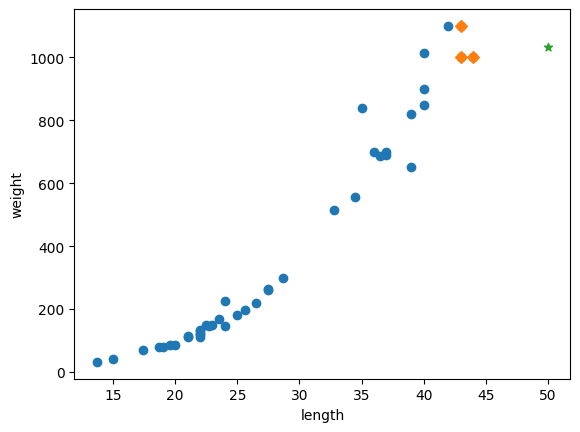

In [38]:
# 50cm 농어의 무게를 판단하기 위해 참조한 이웃(들) 정보
distances, indexes = knr.kneighbors([[50]])

# 훈련 세트의 산점도를 그립니다
plt.scatter(train_input, train_target)

# 훈련 세트 중에서 이웃 샘플만 다시 그립니다
plt.scatter(train_input[indexes], train_target[indexes] , marker='D')

# 50cm 농어 데이터
plt.scatter(50, 1033, marker='*')

plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [39]:
# 이웃 샘플의 타켓 평균을 구해봅니다.
print(np.mean(train_target[indexes]))


1033.3333333333333


In [40]:
# 길이가 100cm 인 농어도 1,033g 으로 예측할겁니다.
print(knr.predict([[100]]))


[1033.33333333]


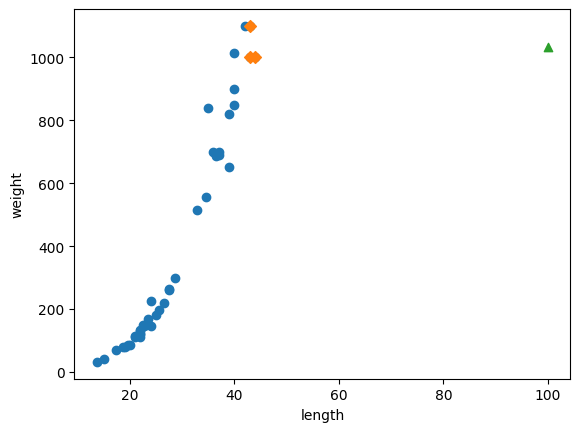

In [41]:
# 한번더 시각화를 해봅시다

# 100cm 농어의 이웃을 구합니다
distances, indexes = knr.kneighbors([[100]])

# 훈련 세트의 산점도를 그립니다
plt.scatter(train_input, train_target)

# 훈련 세트 중에서 이웃 샘플만 다시 그립니다
plt.scatter(train_input[indexes], train_target[indexes], marker='D')

# 100cm 농어 데이터
plt.scatter(100, 1033, marker='^')

plt.xlabel('length')
plt.ylabel('weight')
plt.show()


In [42]:
# KNN Regressor 의 문제점(한계점!)
# KNN 을 사용하여 위 문제를 해결하려면,
# 결국 length 가 더 큰 농어들의 데이터를 포함하여 train 세트를 구성해야 한다.
# 그러나, 이러한 상황이 여의치 않을수 있는겁니다.

# ■ 선형 회귀 (Linear Regression)

In [43]:
# 선형회귀는
# 특성(feature) 가 '한개'인경우 어떤 '직선' 을 학습하는 알고리즘.
# 즉 '특성을 가장 잘 나타낼수 있는 직선'을 찾아야 함.

In [44]:
from sklearn.linear_model import LinearRegression
# sklearn.linear_model 패키지 아래에 선형 모델 관련 알고리즘들이 있다.
# 훈련, 평가, 예측하는 메소드 들은 이전과 모두 동일하다 (scikit-learn 의 장점)
# fit(), score(), predict() 등...

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
```python
class sklearn.linear_model.LinearRegression(
  *,
  fit_intercept=True,
  copy_X=True,
  n_jobs=None,
  positive=False)
```

In [45]:
# 선형 회귀 모델로 훈련
lr = LinearRegression()
lr.fit(train_input, train_target)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [46]:
# 50cm 농어에 대한 예측!
print(lr.predict([[50]]))


[1241.83860323]


In [47]:
# 선형회귀는 농어의 무게를 예측하는 '직선' 을 학습하였을테고
# 이는 아래와 같다.

# 농어의 무게 = a x length + b

![](https://velog.velcdn.com/images/leeeeeyeon/post/7127377b-efd6-46d8-9cf9-09bb7a8cf943/image.png)

In [48]:
# LinearRegression 이 찾은
#  기울기 : coef_    <- 머신러닝에서는 이를 '기울기', '계수' 혹은 '가중치(weight)' 라고도 부름.
#  절편 : intercept_


In [49]:
print(lr.coef_, lr.intercept_)


[39.01714496] -709.0186449535474


- 모델 파라미터 (Model parameter)
  - 머신러닝 알고리즘이 찾아낸 값

- 모델 기반 학습 (Model based learning)
  - 최적의 모델 파라미터를 찾는 학습
  - LinearRegression 은 모델 기반 학습

- 사례 기반 학습 (Instance based learning)
  - 훈련 데이터를 저장한것만으로도 훈련하여 학습
  - KNN 알고리즘은 사례 기반 학습


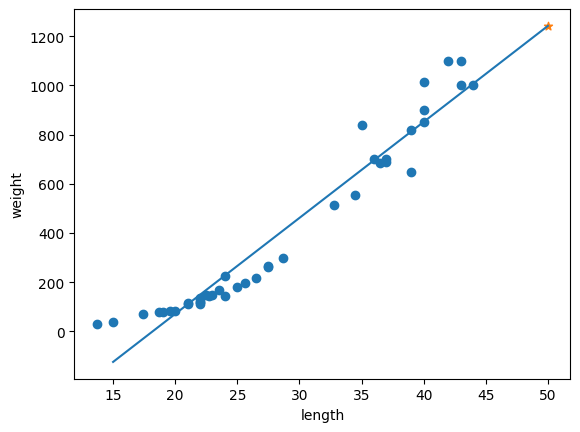

In [50]:
# 농어의 길이 15에서 50까지 직선으로 시각화 합니다.
# 이 직선을 그리려면 앞에서 구한 기울기와 절편을 사용하여
# (15, 15x39-709) 와 (50, 50x39-709) 두 점을 이으면 됩니다.
# train 세트와 산점도를 함께 그려봅니다.

# 훈련 세트의 산점도를 그립니다
plt.scatter(train_input, train_target)
# 15에서 50까지 1차 방정식 그래프를 그립니다
plt.plot([15, 50], [15 * lr.coef_ + lr.intercept_, 50 * lr.coef_ + lr.intercept_])

# 50cm 농어 데이터
plt.scatter(50, 1241.8, marker='*')

plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [51]:
# score 확인
print(lr.score(train_input, train_target))
print(lr.score(test_input, test_target))



0.9398463339976041
0.824750312331356


In [52]:
"""
문제점 고찰 : 전체적으론 train 점수도 높지 않고, test 점수도 매우 낮다. -> underfit 의심!

좌측 하단을 보면 ... weight가 음수가 된다?? 
"""
None

# 다항회귀 (Polynomial Regression)

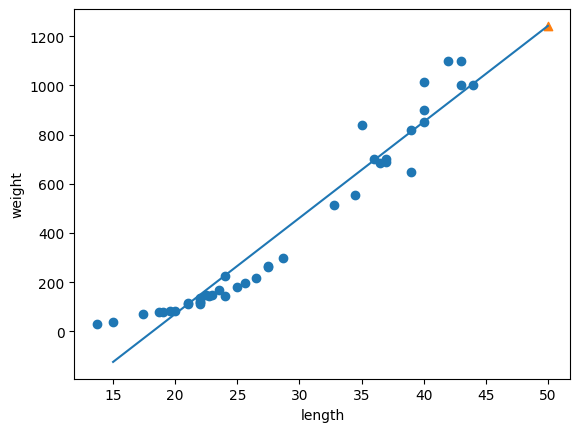

In [53]:
# 다시 시각화를 해서 보면...

plt.scatter(train_input, train_target)
# 15에서 50까지 1차 방정식 그래프를 그립니다
plt.plot([15, 50], [15 * lr.coef_ + lr.intercept_, 50 * lr.coef_ + lr.intercept_])
# 50cm 농어 데이터
plt.scatter(50, 1241.8, marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [54]:
# 최적의 '직선' 을 찾기보다 최적의 '곡선' 을 찾아야 할것이다.
# 마치 아래 그림처럼..  2차 방정식 곡선의 a, b, c  를 찾아내는 것이다!

![](https://velog.velcdn.com/images/leeeeeyeon/post/3aef313a-b68c-4b8d-acfa-0ad0eb989c60/image.png)

In [55]:
"""
이러한 2차 방정식 그래프를 그리려면 '길이를 제곱한 항'이 훈련세트에 추가되어야 합니다.
numpy 를 사용하면 손쉽게 만들수 있다.

무게 = a x 길이² - b x 길이 + c   <=  길이의 제곱과 원래길이 두가지 모두 필요하다.

 length² ←  length
[[ 384.16   19.6 ]
 [ 484.     22.  ]
 [ 349.69   18.7 ]
 [ 302.76   17.4 ]
 [1296.     36.  ]
 ...
 [ 655.36   25.6 ]
 [1764.     42.  ]
 [1190.25   34.5 ]]
"""
None

In [56]:
# 기존 input 을 제곱한것과 나란히 붙이면 됨.
# np.column_stack() 은 매개변수가 tuple 이어야 한다!
train_poly = np.column_stack((train_input ** 2, train_input))
test_poly = np.column_stack((test_input ** 2, test_input))


In [57]:
# 확인
train_poly[:10]


array([[ 384.16,   19.6 ],
       [ 484.  ,   22.  ],
       [ 349.69,   18.7 ],
       [ 302.76,   17.4 ],
       [1296.  ,   36.  ],
       [ 625.  ,   25.  ],
       [1600.  ,   40.  ],
       [1521.  ,   39.  ],
       [1849.  ,   43.  ],
       [ 484.  ,   22.  ]])

In [58]:
print(train_poly.shape, test_poly.shape)

(42, 2) (14, 2)


In [59]:
# 이제 train_poly 를 사용해 선형 회귀 모델을 다시 훈련해보자
# 훈련 세트에 제곱항을 추가했지만, '타킷 값은 그대로 사용'한다.

# 훈련한 다음 50cm 짜리 농어에 대해 무게를 예측해 볼겁니다.
# 앞서 훈련 세트에서 했던 것처럼 테스트 할때에도
# 이 모델에 '농어길이의 제곱'과 '원래 길이'를 함께 넣어주어야 합니다


In [60]:
lr = LinearRegression()
lr.fit(train_poly, train_target)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [61]:
# 50cm 농어의 무게 예측하기!
print(lr.predict([[50**2,50]]))


[1573.98423528]


In [62]:
# 모델이 훈련한 '계수'와 '절편' 확인
print(lr.coef_, lr.intercept_)

[  1.01433211 -21.55792498] 116.0502107827827


In [63]:
# 2차 방정식은 '직선' 형태가 아닌데 선형회귀 라고 말할수 있나?

"""
무게 = 1.01(length)** 2 - 21.56(length) + 116.05

위의 식으로 무게는 '길이 제곱'과 '길이'의 '선형관계'로 표현 가능

"""
None

In [64]:
# 이러한 방정식을 다항식 (polynomial) 이라 부르며
# 다항식을 사용한 선형 회귀를 다항회귀 (polynomial regression) 이라 한다


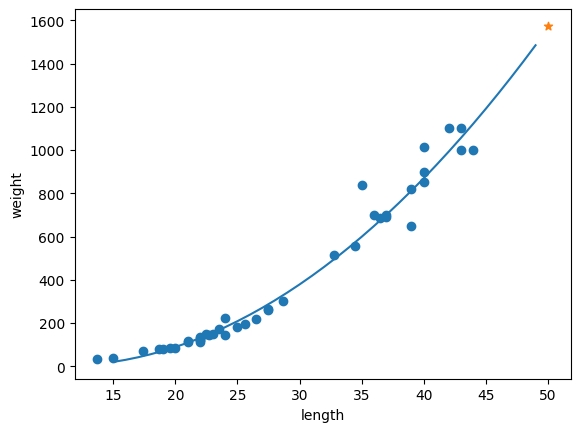

In [65]:
# 구간별 직선을 그리기 위해 15에서 49까지 정수 배열을 만듭니다
point = np.arange(15, 50)

# 훈련 세트의 산점도를 그립니다
plt.scatter(train_input, train_target)

# 15에서 49까지 2차 방정식 그래프를 그립니다
plt.plot(point, ((1.01 * point**2) - (21.56 * point) + 116.05))

# 50cm 농어 데이터
plt.scatter([50], [1574], marker='*')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [66]:
# 훈련세트와 테스트 세트의 R² 점수 평가
print(lr.score(train_poly, train_target))
print(lr.score(test_poly, test_target))



0.9706807451768623
0.9775935108325122


### 선형회귀를 사용하여 train 세트 범위 밖의 샘플 예측하기
- 문제 해결 단계
1. KNN 사용시 가장 큰 문제점 -> train 세트 밖의 샘플 예측이 어렵다! (무조건 가장 가까운 샘플의 타깃을 평균하여 예측함)

2. 위 문제를 해결하기 위해 **선형회귀(LinearRegression)** 사용.   

3. 가장 잘 맞는 직선의 방정식 찾음 → 최적의 기울기와 절편을 구함. → train 세트 범위를 벗어난 데이터도 잘 예측함.

4. 그러나 모델이 너무 단순하여 농어의 무게가 음수 일수도 있슴이 확인되었다!
5. 이를 해결하기 위해 '**다항회귀**' 사용. 2차 방정식의 그래프 형태를 학습하여 훈련 세트가 분포된 형태를 잘 표현함. → 단순한 선형회귀 보다 성능도 훨씬 좋아짐.

## 여기까지의 문제점 고찰

In [67]:
# 원본 데이터에는 농어의 Length(길이) 말고도 높이(Height) 와 두께(Width) 도 있었다.
# ↓ 확인해보자

fish_df.columns


Index(['Species', 'Weight', 'Length', 'Diagonal', 'Height', 'Width'], dtype='object')

# ■ 특성공학, 다중회귀 (multiple regression)

In [68]:
# 입력데이터가 농어의 '길이' 뿐인가?
# 선형회귀는 '특성' 많을수록 좋은 효과를 기대해볼수 있다.
# 직전에는 '하나의 특성'을 사용하여 선형 회귀 모델을 훈련시켜보았다.
# '여러개의 특성'을 사용한 선형 회귀를 다중회귀 (multiple regression) 이라 한다

In [69]:
# 이전 예제에서 '한개의 특성'을 사용했을때 선형회귀 모델이 학습하는 것은 '2차원 평면상의직선(곡선)'입니다.
# 2개의 특성을 학습하면 무엇을 학습하게 될까요?

![](https://media.licdn.com/dms/image/D4D12AQEhqo6dQF0_IA/article-cover_image-shrink_720_1280/0/1698041185106?e=2147483647&v=beta&t=8YFNXke-HHsGaUsq63x48xuUFfNYdbSTIPhgdH45gQI)


In [70]:
# '특성' 이 2개 이면 '평면' 을 학습하게 됩니다
# 특성이 2개 + 타겟값 1개  => 3차원 공간을 형성하게 됨.

# 이때 선형 회귀 방정식은

# 타킷 = a x feature1 + b x feature2 + c (절편)  의 평면이 됩니다.

# 만약 특성에 3개 이상이면?   =>  그림으로는 그릴수 없는 초평면..

# 선형회귀를 단순한 직선이나 평면으로 생각하여 성능이 무조건 낮다고 오해해서는 안됩니다.
# 특성이 많은 고차원에서 선형회귀는 매우 복잡한 모델도 표현할수도 있다!


## 특성공학 이란
feature enginering

- 기존의 특성을 사용해 새로운 특성을 뽑아내는 작업

In [71]:
# 이번 예제에서
# 농어의 '길이' 뿐 아니라 농어의 '높이(Height)'와 '두께(Width)'도 함께 사용.
# 3개의 특성에 각각 제곱하여 추가
# 각 특성을 서로 곱해서 '또 다른 특성'도 만들어 보자

# 이렇게 기존의 특성을 사용해 새로운 특성을 뽑아내는 작업을 특성공학 (feature enginering) 이라 한다

## 데이터 준비

In [72]:
fish_df # 확인

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...
154,Smelt,12.2,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,14.3,15.2,2.8728,2.0672


In [73]:
# 농어의 길이, 높이, 두께
                                         
perch_df = fish_df[fish_df.Species == 'Perch'][['Length', 'Height','Width']]
perch_df

,Length,Height,Width
72,8.4,2.1120,1.4080
73,13.7,3.5280,1.9992
74,15.0,3.8240,2.4320
75,16.2,4.5924,2.6316
76,17.4,4.5880,2.9415
77,18.0,5.2224,3.3216
78,18.7,5.1992,3.1234
79,19.0,5.6358,3.0502
80,19.6,5.1376,3.0368
81,20.0,5.0820,2.7720


In [74]:
# numpy 배열로 변환한후 선형회귀 모델을 훈련시켜 볼 거다

# numpy 배열 변환
perch_full = perch_df.to_numpy()
perch_full


array([[ 8.4   ,  2.112 ,  1.408 ],
       [13.7   ,  3.528 ,  1.9992],
       [15.    ,  3.824 ,  2.432 ],
       [16.2   ,  4.5924,  2.6316],
       [17.4   ,  4.588 ,  2.9415],
       [18.    ,  5.2224,  3.3216],
       [18.7   ,  5.1992,  3.1234],
       [19.    ,  5.6358,  3.0502],
       [19.6   ,  5.1376,  3.0368],
       [20.    ,  5.082 ,  2.772 ],
       [21.    ,  5.6925,  3.555 ],
       [21.    ,  5.9175,  3.3075],
       [21.    ,  5.6925,  3.6675],
       [21.3   ,  6.384 ,  3.534 ],
       [22.    ,  6.11  ,  3.4075],
       [22.    ,  5.64  ,  3.525 ],
       [22.    ,  6.11  ,  3.525 ],
       [22.    ,  5.875 ,  3.525 ],
       [22.    ,  5.5225,  3.995 ],
       [22.5   ,  5.856 ,  3.624 ],
       [22.5   ,  6.792 ,  3.624 ],
       [22.7   ,  5.9532,  3.63  ],
       [23.    ,  5.2185,  3.626 ],
       [23.5   ,  6.275 ,  3.725 ],
       [24.    ,  7.293 ,  3.723 ],
       [24.    ,  6.375 ,  3.825 ],
       [24.6   ,  6.7334,  4.1658],
       [25.    ,  6.4395,  3

In [75]:
# target 값 확인하기
perch_weight


array([   5.9,   32. ,   40. ,   51.5,   70. ,  100. ,   78. ,   80. ,
         85. ,   85. ,  110. ,  115. ,  125. ,  130. ,  120. ,  120. ,
        130. ,  135. ,  110. ,  130. ,  150. ,  145. ,  150. ,  170. ,
        225. ,  145. ,  188. ,  180. ,  197. ,  218. ,  300. ,  260. ,
        265. ,  250. ,  250. ,  300. ,  320. ,  514. ,  556. ,  840. ,
        685. ,  700. ,  700. ,  690. ,  900. ,  650. ,  820. ,  850. ,
        900. , 1015. ,  820. , 1100. , 1000. , 1100. , 1000. , 1000. ])

In [76]:
# train 세트와 test 세트 나누기

train_input, test_input, train_target, test_target = \
    train_test_split(perch_full, perch_weight, random_state=42)

train_input.shape, test_input.shape 

((42, 3), (14, 3))


## transformer (변환기)
사이킷럿에서 '특성(feature)'를 만들거나 전처리 하기 위해 제공되는 클래스들을 transformer 라 한다.

사이킷 런의 모델 클래스에 일관된 fit(), score(), predict() 메소드가 있는 것처럼,

transformer 클래스는 fit(),  transform() 메소드를 제공함

In [77]:
# ※ 앞서 배운 LinearRegression 같은 사이킷런 모델 클래스는 estimator(추정기) 라고 부릅니다.

In [78]:
# 이번에 사용할 변환기는 PolynomialFeatures 클래스
# preprocessing 패키지에 있다.

from sklearn.preprocessing import PolynomialFeatures


https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures

```python
class sklearn.preprocessing.PolynomialFeature(
  degree=2,
  *,
  interaction_only=False,
  include_bias=True,
  order='C')
```

In [79]:
# ↓ 일단 위 클래스가 어떻게 동작하는지 확인해봅니다

In [80]:
# 2개의 특성 2 와 3으로 이루어진 샘플 하나를 적용해보겠습니다.

poly = PolynomialFeatures()
# 먼저 fit() (훈련) 을 해야 변환 (transform) 이 가능합
poly.fit([[2,3]])
poly.transform([[2,3]])


array([[1., 2., 3., 4., 6., 9.]])

In [81]:
# ※ 훈련(fit()) 해야 변환(transform())이 가능합니다
# 사이킷런의 일관된 api 때문에 두단계로 나뉘어져 있다.
# 두 메소드를 하나로 붙인 합친 fit_transform() 도 있습니다

In [82]:
# ↑ 2개의 특성(원소)을 가진 샘플[2, 3] 이 6개의 특성을 가진 샘플 [1. 2. 3. 4. 6. 9.] 로 변환됨.

# fit() : 새롭게 만들 특성 조합을 찾음
# transform() : 실제로 데이터를 변환

# PolynomialFeatures 클래스는 '기본적'으로
# 각 특성을 제곱한 항을 추가하고 특성끼리 서로 곱한 항을 추가



In [83]:
# include_bias=False 로 지정하여 다시 특성을 변환
poly = PolynomialFeatures(include_bias=False)
poly.fit([[2, 3]])
print(poly.transform([[2, 3]]))


[[2. 3. 4. 6. 9.]]


In [84]:
# include_bias=False 를 꼭 지정할 필요는 없으나...
# 이를 지정해주지 않아도 사이킷럿 모델은 자동으로 특성에 추가된 절편 항을 무시합니다.
# 하지만, 여기에서는 혼돈을 피하기 위해 명시적으로 지정한겁니다.

In [85]:
# 이제 이 방식으로 train_input 에 적용합니다.
poly = PolynomialFeatures(include_bias=False)
poly.fit(train_input)

# 변환된 데이터 저장하고 확인
train_poly = poly.transform(train_input)
train_poly.shape


(42, 9)

In [86]:
# ↑ 어떻게 (42, 9)  가 만들어 진걸까?
# ↓ PolynomialFeatures 클래스는 9개의 특성이 어떻게 만들어졌는지 확인하는 아주 좋은 방법을 제공한다.

In [87]:
# get_feature_names_out(): 각 특성이 어떻게 만들어졌는지 확인
poly.get_feature_names_out()


array(['x0', 'x1', 'x2', 'x0^2', 'x0 x1', 'x0 x2', 'x1^2', 'x1 x2',
       'x2^2'], dtype=object)

In [88]:
# ['x0', 'x1', 'x2', 'x0^2', 'x0 x1', 'x0 x2', 'x1^2', 'x1 x2', 'x2^2']
#  'x0' 는 첫번째 특성
#  'x0^2' 는 첫번째 특성의 제곱
#  'x0 x1' 은 첫번째 특성과 두번째 특성의 곱


In [89]:
# 이제 이 변환기로 test 세트도 변환시키겠습니다
test_poly = poly.transform(test_input)
test_poly.shape


(14, 9)

In [90]:
# 잠깐!
#  꼭 훈련세트에 적용했던 변환기로 테스트 세트를 변환해야 할까요?

#  사실 PolynomialFeatures 클래스는 fit() 에서 만들 특성의 조합을 준비하기만 하고,
# 별도의 통계값을 구하지 않습니다.  따라서 테스트 세트를 따로 변환해도 됩니다.

# 하지만!  앞에서 설명했듯이
# ★항.상.!  훈련세트를 기준으로 테스트 세트를 변환★하는 습관을 들이는 것이 좋습니다

## 다중 회귀 모델 훈련

In [91]:
# 다중 회귀 모델 훈련도 기본적으로 선형 회귀 모델 훈련하는 것과 같다.
#  다만 '여러개의 특성'을 사용한다!

In [92]:
lr = LinearRegression()
lr.fit(train_poly, train_target)
print(lr.score(train_poly, train_target))


0.9903557670312702


In [93]:
# 테스트 세트에 대한 점수도 확인해보자
print(lr.score(test_poly, test_target))

0.971237620746185


In [94]:
# 특성을 더 많이 추가하면 어떨까?
# 3제곱, 4제곱 항을 넣는 거죠
# PolynomialFeatures 클래스의 degree= 매개변수사용하여 필요한 고차항의 최대차수를 지정할수 있다.

# ↓ 5제곱 까지의 특성을 만들어 출력해봅시다.

In [95]:
poly = PolynomialFeatures( degree=5, include_bias=False)

poly.fit(train_input)
train_poly = poly.transform(train_input)
test_poly = poly.transform(test_input)

print(train_poly.shape)
print(test_poly.shape)


(42, 55)
(14, 55)


In [96]:
# 과연 점수는!
lr.fit(train_poly, train_target)
print(lr.score(train_poly, train_target))

0.9999999999997237


In [97]:
# 테스트 세트에 대한 점수는?
print(lr.score(test_poly, test_target))

-129.88001924129384


In [ ]:
# ↑ 헉!?




![](https://miro.medium.com/v2/resize:fit:1125/1*_7OPgojau8hkiPUiHoGK_w.png)

# 규제 (regularization)

**규제 (regularization)** 은 머신러닝 모델이 train 세트를 너무 과도하게 학습하지 못하도록 훼방하는 것

즉, 모델이 훈련세트에 과대적합 (overfit) 되지 않도록 만드는 거다.

선형 회귀 모델의 경우 특성에 곱해지는 계수 (또는 기울기) 의 크기를 작게 만드는 일입니다.

아래 그림을 살펴봅니다

![](https://www.analyticsvidhya.com/wp-content/uploads/2015/02/underfitting-overfitting.png)

오른쪽의 그림은 train 세트를 과도하게 학습했고,  가운데는 기울기를 줄여서 보다 보편적인 (general) 패턴을 학습하고 있습니다

In [ ]:
# 앞서 55개의 특성으로 훈련한 선형 회귀 모델의 계수를 규제하여
# 훈련 세트의 점수를 낮추고 대신 테스트 점수를 높여 보겠습니다

In [ ]:
# 특성의 스케일도 고려해야 한다.
# 특성의 스케일이 정규화되지 않으면 여기에 곱해지는 계수 값도 차이 나게 됨.
# 일반적으로 선형 회귀 모델에 규제를 적용할 때 계수 값의 크기가 서로 많이 다르면 공정하게 제어되지 않는다.
# 그렇다면 규제를 적용하기 전에 먼저 정규화를 해야 한다!

# StandardScaler 변환기를 사용해보자

In [98]:
from sklearn.preprocessing import StandardScaler

https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler

```python
class sklearn.preprocessing.StandardScaler(
  *,
  copy=True,
  with_mean=True,
  with_std=True)
```


In [100]:
ss = StandardScaler()
ss.fit(train_poly)
train_scaled = ss.transform(train_poly)
test_scaled = ss.transform(test_poly)

# train 세트에서 학습한 평균과 표준편차는 StandardScaler 객체의 mean_, scale_ 속성에 저장됩니다.
# 특성마다 계산하게 되므로 55개의 평균과 표준편차가 들어 있습니다.

ss.mean_, ss.scale_

(array([2.84452381e+01, 8.04177619e+00, 4.82055476e+00, 8.85315000e+02,
        2.53470948e+02, 1.51956220e+02, 7.29276742e+01, 4.36967156e+01,
        2.62853281e+01, 2.97326070e+04, 8.59774772e+03, 5.15176747e+03,
        2.49656208e+03, 1.49553817e+03, 8.99087988e+02, 7.27845314e+02,
        4.35963245e+02, 2.62077075e+02, 1.58112864e+02, 1.05917983e+06,
        3.08417994e+05, 1.84632019e+05, 9.01174973e+04, 5.39424625e+04,
        3.23950805e+04, 2.64197426e+04, 1.58147036e+04, 9.49827765e+03,
        5.72355360e+03, 7.77060032e+03, 4.65212847e+03, 2.79466584e+03,
        1.68451523e+03, 1.01877250e+03, 3.93876111e+07, 1.15189511e+07,
        6.88783177e+06, 3.37848356e+06, 2.02012802e+06, 1.21163040e+06,
        9.93702300e+05, 5.94216722e+05, 3.56448011e+05, 2.14482543e+05,
        2.93083339e+05, 1.75288678e+05, 1.05174815e+05, 6.33063832e+04,
        3.82250476e+04, 8.66772369e+04, 5.18541727e+04, 3.11238569e+04,
        1.87420990e+04, 1.13226020e+04, 6.86230209e+03]),
 array

In [ ]:
# 릿지: 계수를 제곱한 값을 기준으로 규제를 적용.  (일반적으로 릿지 선호)
# 라쏘: 계수의 절댓값을 기준으로 규제를 적용.

# 두 알고리즘 모두 계수의 크기를 줄이지만, 라쏘는 아예 0으로 만들 수도 있다.


# 릿지 회귀 : Ridge Regression

In [101]:
from sklearn.linear_model import Ridge

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html#sklearn.linear_model.Ridge

```python
class sklearn.linear_model.Ridge(
  alpha=1.0,
  *,
  fit_intercept=True,
  copy_X=True,
  max_iter=None,
  tol=0.0001,
  solver='auto',
  positive=False,
  random_state=None)
```

In [102]:
ridge = Ridge()
ridge.fit(train_scaled, train_target)
print(ridge.score(train_scaled, train_target))


0.9896217956447125


In [103]:
print(ridge.score(test_scaled, test_target))

0.9788853860988027


In [ ]:
# alpha 값 : 규제의 강도 조절

# 릿지 와 라쏘 모델을 사용할 때 규제의 양을 임의로 조절할 수 있습니다.
# 모델 객체를 만들때 alpha 매개변수로 규제의 강도를 조절할수 있다
# alpha 값이 크면 규제강도가 세지므로 계수 값을 더 줄이고 조금 더 과소 적합 되도록 유도합니다.
# alpha 값이 작으면 계수를 줄이는 역할이 줄어들고 선형회귀 모델과 유사해지므로 과대적합 될 가능성이 큽니다.

# alpha 값은 hyper parameter 입니다 ↓

## hyperparameter

In [ ]:
# hyperparameter : 사전에 직접 지정해 주어야 하는 세팅값

# alpha 값 처럼  사전에 사람이 직접 지정해주어야 하는 값들을 하이퍼 파라미터 (hyperparameter) 라고 부릅니다.
# 사이킷런 과 같은 머신러닝 라이브러리에서 하이퍼 파라미터는 클래스와 메소드의 매개변수로 표현됨.


### 적절한 hyperparameter 찾기

In [ ]:
# 적절한 alpha 값을 찾는 한가지 방법은 alpha 값에 대한 결정계수(R²) 값의 그래프를 그려보는 겂입니다.
# train 세트와 test 세트의 점수가 가장 가까운 지점이 최적의 alpha 값이 됩니다.

In [105]:
# alpha 값을 바꿀때 마다 score() 결과값들을 저장할 리스트 준비
train_score = []
test_score = []

In [ ]:
# alpha 값을 0.001 에서 100 까지 10 배씩 늘려가며 릿지 회귀 모델을 훈련한 다음
# train 세트와 test 세트의 점수를 파이썬 리스트에 저장합니다.

In [106]:
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]

for alpha in alpha_list:
    # 릿지 모델을 만듭니다
    ridge = Ridge(alpha = alpha)
    
    # 릿지 모델을 훈련합니다
    ridge.fit(train_scaled, train_target)

    # 훈련 점수와 테스트 점수를 저장합니다
    train_score.append(ridge.score(train_scaled, train_target))
    test_score.append(ridge.score(test_scaled, test_target))


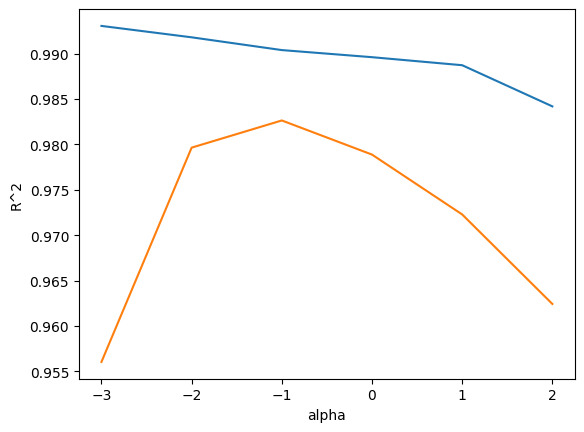

In [107]:
plt.plot(np.log10(alpha_list), train_score)
plt.plot(np.log10(alpha_list), test_score)

plt.xlabel('alpha')
plt.ylabel('R^2')
plt.show()

In [ ]:
"""
↑ 위의 파란색이 train 세트 그래프
아래 주황색이 test 세트 그래프


왼쪽을 보면 train 세트와 test 세트의 점수차이가 아주 큽니다.
    => train 세트에는 잘 맞고 test 세트에는 형편없는 과대적합(overfit)의 전형적인 모습


반대로 오른쪽 편은  train 세트와 test 셑트는 점수가 모두 낮아지는 경향을 보이는 과소적합 (underfit) 으로 가는 모습


적절한 alpha 값은 두 그래프가 가장 가깝고 테스트 점수가 가장 높은 -1,  즉 0.1 입니다.
alpha 값을 0.1 로 세팅하여 최종 모델을 훈련해봅니다.
"""
None


In [108]:
# 최적의 alpha 값 세팅

ridge = Ridge(alpha = 0.1)
ridge.fit(train_scaled, train_target)

print(ridge.score(train_scaled, train_target))
print(ridge.score(test_scaled, test_target))

0.990404845594141
0.9826465162736733


# 라쏘 회귀 (Lasso Regression)

In [ ]:
# 기본적으로 Ridge 를 사용했던 방식과 매우 비슷 합니다.

In [109]:
from sklearn.linear_model import Lasso

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html#sklearn.linear_model.Lasso

```python
class sklearn.linear_model.Lasso(
  alpha=1.0,
  *,
  fit_intercept=True,
  precompute=False,
  copy_X=True,
  max_iter=1000,
  tol=0.0001,
  warm_start=False,
  positive=False,
  random_state=None,
  selection='cyclic')
```

In [110]:
lasso = Lasso()
lasso.fit(train_scaled, train_target)

print(lasso.score(train_scaled, train_target))
print(lasso.score(test_scaled, test_target))


0.9898014198970121
0.9798798667260247


In [114]:
# 적절할 alpha 값 찾기
train_score = []
test_score = []

alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]
for alpha in alpha_list:
    # 라쏘 모델을 만듭니다
    lasso = Lasso(alpha=alpha, max_iter= 10000)  # max_iter : 최적의 계수를 찾기 위한 반복 계산 횟수


    # 라쏘 모델을 훈련합니다
    lasso.fit(train_scaled, train_target)

    # 훈련 점수와 테스트 점수를 저장합니다
    train_score.append(lasso.score(train_scaled, train_target))
    test_score.append(lasso.score(test_scaled, test_target))


F:\KDT2508\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.872e+04, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(
F:\KDT2508\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.300e+04, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(


In [ ]:
# ↓ train_score 와 test_score 리스트를 사용하여 그래프를 그립니다.
# 이 그래프도 x 축은 로그 스케일로 바꿔 그려봅니다.

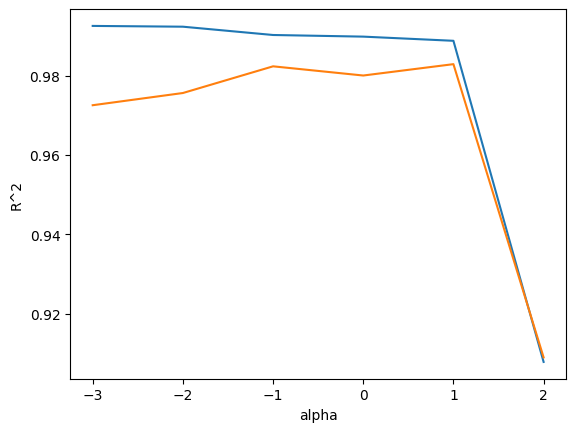

In [115]:
plt.plot(np.log10(alpha_list), train_score)
plt.plot(np.log10(alpha_list), test_score)

plt.xlabel('alpha')
plt.ylabel('R^2')
plt.show()

In [116]:
# 최적의 alpha 값으로 다시 훈련

lasso = Lasso(alpha = 10)
lasso.fit(train_scaled, train_target)

print(lasso.score(train_scaled, train_target))
print(lasso.score(test_scaled, test_target))


0.988820885788649
0.9823020708550178


In [117]:
lasso.coef_

array([ 0.        ,  0.        ,  0.        , 13.11036343, 55.12266859,
       41.48994624,  0.        ,  0.        , 13.9830843 ,  0.        ,
       43.4392343 ,  4.64928255, 48.51500022,  6.26668787, 11.80207049,
        0.        ,  0.        , 13.35211297, 22.11736679,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
       19.18672642,  0.        ,  0.        ,  0.        , 15.53954944,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        , 18.55402184,
        0.        ,  0.        ,  0.        ,  0.        , 14.99032734,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ])

In [118]:
# 라쏘 모델은 계수 값을 아예 0으로 만들수도 있습니다.
# 라쏘 모델의 계수는 coef_ 속성에 저장되어 있습니다.  이 중에 0 인것을 세어보자.
print(np.sum(lasso.coef_==0))


40


In [ ]:
# 라쏘는 릿지와 달리 모델의 '유용한 특성'을 골라내는 용도로도 활용 가능 b/c 유용하지 않을것은 0으로 바꾸기 때문 

# 모델의 과대 적합을 제어하기
문제 해결과정